In [58]:
import pandas as pd

In [59]:
import matplotlib.pyplot as plt

In [60]:
import seaborn as sb

In [61]:
import numpy as np

In [62]:
df_original = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-04-07/tdf_winners.csv")

In [63]:
df_original.head()

,edition,start_date,winner_name,winner_team,distance,time_overall,time_margin,stage_wins,stages_led,height,weight,age,born,died,full_name,nickname,birth_town,birth_country,nationality
0,1,1903-07-01,Maurice Garin,La Française,2428.0,94.553889,2.989167,3,6,1.62,60.0,32,1871-03-03,1957-02-19,NaN,The Little Chimney-sweep,Arvier,Italy,France
1,2,1904-07-02,Henri Cornet,Conte,2428.0,96.098611,2.270556,1,3,NaN,NaN,19,1884-08-04,1941-03-18,NaN,Le rigolo (The joker),Desvres,France,France
2,3,1905-07-09,Louis Trousselier,Peugeot–Wolber,2994.0,NaN,NaN,5,10,NaN,NaN,24,1881-06-29,1939-04-24,NaN,Levaloy / Trou-trou,Paris,France,France
3,4,1906-07-04,René Pottier,Peugeot–Wolber,4637.0,NaN,NaN,5,12,NaN,NaN,27,1879-06-05,1907-01-25,NaN,NaN,Moret-sur-Loing,France,France
4,5,1907-07-08,Lucien Petit-Breton,Peugeot–Wolber,4488.0,NaN,NaN,2,5,NaN,NaN,24,1882-10-18,1917-12-20,Lucien Georges Mazan,Lucien Petit-Breton,Plessé,France,France


In [64]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   edition        106 non-null    int64  
 1   start_date     106 non-null    object 
 2   winner_name    106 non-null    object 
 3   winner_team    106 non-null    object 
 4   distance       106 non-null    float64
 5   time_overall   98 non-null     float64
 6   time_margin    98 non-null     float64
 7   stage_wins     106 non-null    int64  
 8   stages_led     106 non-null    int64  
 9   height         66 non-null     float64
 10  weight         67 non-null     float64
 11  age            106 non-null    int64  
 12  born           106 non-null    object 
 13  died           56 non-null     object 
 14  full_name      46 non-null     object 
 15  nickname       74 non-null     object 
 16  birth_town     106 non-null    object 
 17  birth_country  106 non-null    object 
 18  nationalit

In [65]:
df_original.columns

Index(['edition', 'start_date', 'winner_name', 'winner_team', 'distance',
       'time_overall', 'time_margin', 'stage_wins', 'stages_led', 'height',
       'weight', 'age', 'born', 'died', 'full_name', 'nickname', 'birth_town',
       'birth_country', 'nationality'],
      dtype='object')

In [66]:
df_cleaned = df_original.copy()

In [67]:
df_cleaned = df_cleaned.drop_duplicates()

In [68]:
df_cleaned.isna().sum()

edition           0
start_date        0
winner_name       0
winner_team       0
distance          0
time_overall      8
time_margin       8
stage_wins        0
stages_led        0
height           40
weight           39
age               0
born              0
died             50
full_name        60
nickname         32
birth_town        0
birth_country     0
nationality       0
dtype: int64

In [69]:
df_cleaned = df_cleaned.dropna(subset = ['time_overall', 'time_margin', 'edition'])

In [70]:
df_cleaned.isna().sum()

edition           0
start_date        0
winner_name       0
winner_team       0
distance          0
time_overall      0
time_margin       0
stage_wins        0
stages_led        0
height           33
weight           32
age               0
born              0
died             50
full_name        55
nickname         28
birth_town        0
birth_country     0
nationality       0
dtype: int64

In [71]:
print(df_cleaned['edition'].value_counts().sort_index())

edition
1      1
2      1
11     1
12     1
13     1
      ..
102    1
103    1
104    1
105    1
106    1
Name: count, Length: 98, dtype: int64


In [72]:
df_cleaned[['edition', 'time_overall', 'time_margin', 'distance']].head(10)

,edition,time_overall,time_margin,distance
0,1,94.553889,2.989167,2428.0
1,2,96.098611,2.270556,2428.0
10,11,197.900000,0.135556,5287.0
11,12,200.480000,0.016944,5380.0
12,13,231.120833,1.715000,5560.0
13,14,228.603611,0.965833,5503.0
14,15,221.840556,0.305000,5485.0
15,16,222.135000,0.694722,5375.0
16,17,222.258333,0.508333,5386.0
17,18,226.305833,0.593056,5425.0


In [73]:
df_sorted = df_cleaned.sort_values('edition')

In [74]:
df_sorted[['edition', 'time_overall', 'time_margin', 'distance']].head(10)

,edition,time_overall,time_margin,distance
0,1,94.553889,2.989167,2428.0
1,2,96.098611,2.270556,2428.0
10,11,197.900000,0.135556,5287.0
11,12,200.480000,0.016944,5380.0
12,13,231.120833,1.715000,5560.0
13,14,228.603611,0.965833,5503.0
14,15,221.840556,0.305000,5485.0
15,16,222.135000,0.694722,5375.0
16,17,222.258333,0.508333,5386.0
17,18,226.305833,0.593056,5425.0


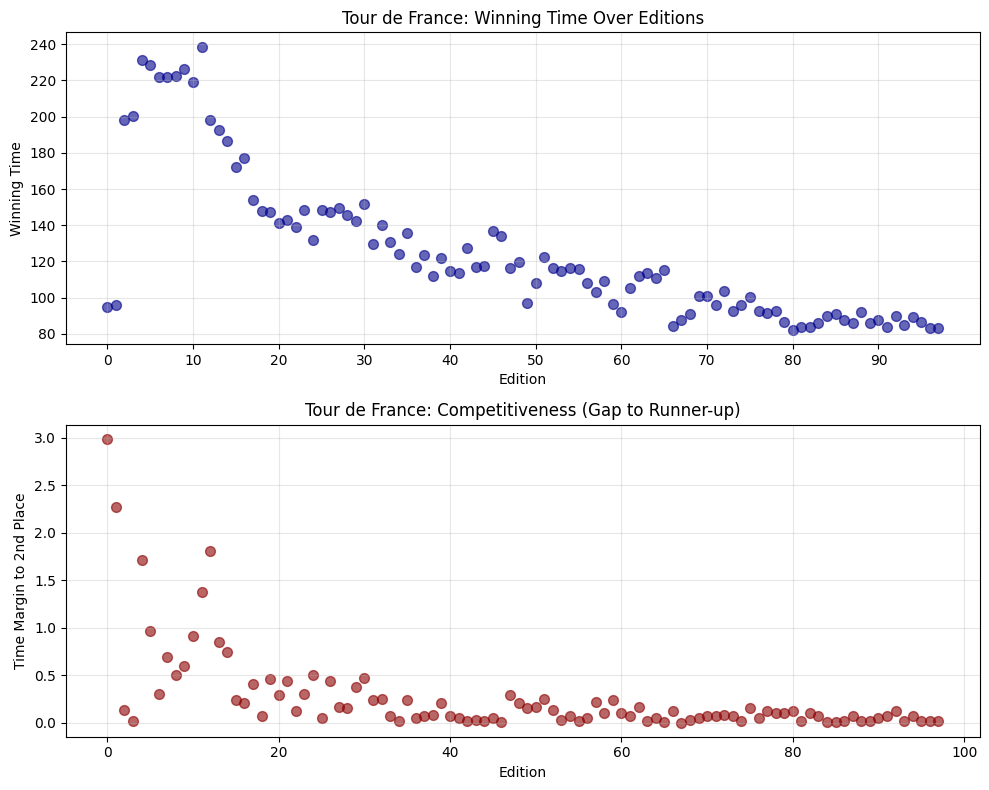

In [75]:
fig, (ax1,ax2) = plt.subplots(2,1, figsize = (10,8))
#x1.plot(df_sorted['edition'], df_sorted['time_overall'], marker='o', linewidth=2)
ax1.scatter(range(len(df_sorted)), df_sorted['time_overall'].values, s=50, color='darkblue', alpha=0.6)
ax1.set_xlabel('Edition')
ax1.set_ylabel('Winning Time')
ax1.set_title('Tour de France: Winning Time Over Editions')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, len(df_sorted), 10))
#ax2.plot(df_sorted['edition'], df_sorted['time_margin'], marker='o', color='red', linewidth=2)
ax2.scatter(range(len(df_sorted)), df_sorted['time_margin'].values, s=50, color='darkred', alpha=0.6)
ax2.set_xlabel('Edition')
ax2.set_ylabel('Time Margin to 2nd Place')
ax2.set_title('Tour de France: Competitiveness (Gap to Runner-up)')
ax2.grid(True, alpha=0.3)
ax1.set_xticks(range(0, len(df_sorted), 10))
plt.tight_layout()
plt.show()

- The winning time has been reducing with each edition. 
- The margin betwen the wiiner and the first runner up has aslo been reducing apart from a few instances. 
- This implies thet the athletes are in fact getting better at their craft and not lazier.
- We cannot say some are getting better bikes because the margin is reducing even as the time take to win is reducing.

In [76]:
df_sorted[['edition', 'winner_team','winner_name', 'stages_led', 'stage_wins']].head(10)

,edition,winner_team,winner_name,stages_led,stage_wins
0,1,La Française,Maurice Garin,6,3
1,2,Conte,Henri Cornet,3,1
10,11,Peugeot–Wolber,Philippe Thys,8,1
11,12,Peugeot–Wolber,Philippe Thys,15,1
12,13,La Sportive,Firmin Lambot,2,1
13,14,La Sportive,Philippe Thys,14,4
14,15,La Sportive,Léon Scieur,14,2
15,16,Peugeot–Wolber,Firmin Lambot,3,0
16,17,Automoto–Hutchinson,Henri Pélissier,6,3
17,18,Automoto,Ottavio Bottecchia,15,4


In [77]:
df_sorted['winner_name'].nunique()

56

In [78]:
df_sorted['winner_team'].nunique()

48

In [79]:
winners_per_team = df_sorted.groupby('winner_team')['winner_name'].nunique().reset_index()

In [80]:
winners_per_team.columns = ['Team', 'Number_of_Winners']

In [81]:
winners_per_team = winners_per_team.sort_values('Number_of_Winners', ascending=False)

In [82]:
print(winners_per_team.head(10))

                   Team  Number_of_Winners
16               France                  8
1         Alcyon–Dunlop                  3
18                Italy                  3
4   Automoto–Hutchinson                  3
44             Team Sky                  3
20          La Sportive                  3
7               Belgium                  2
2                Astana                  2
21        La Vie Claire                  2
39          Switzerland                  2


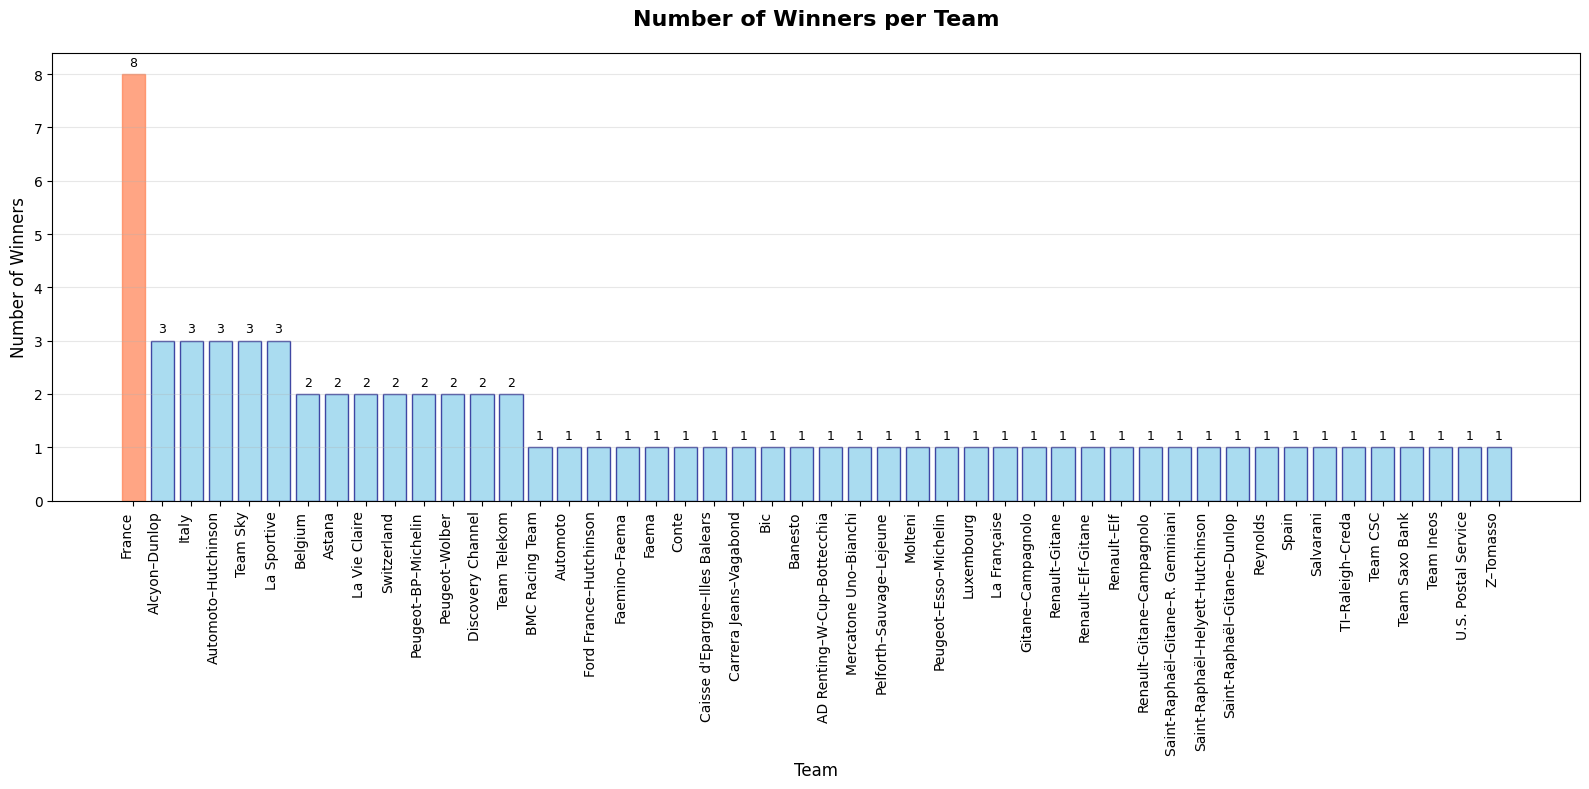

In [83]:
plt.figure(figsize=(16, 8))
bars = plt.bar(winners_per_team['Team'], winners_per_team['Number_of_Winners'], color='skyblue', edgecolor='navy', alpha=0.7)
for i in range(min(1, len(bars))):
    bars[i].set_color('coral')
plt.title('Number of Winners per Team', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Winners', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, (team, count) in enumerate(zip(winners_per_team['Team'], winners_per_team['Number_of_Winners'])):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

- From the question we are asked to visualize the winners per stage type but the data does not have the stage type.
- Instead I decided to visualize with team was the actaully the winning team. As seen in the plot above, the winning team is "France" 
- It produced 8 winners from all the races

In [84]:
df_sorted[['age', 'stages_led']].head(10)

,age,stages_led
0,32,6
1,19,3
10,23,8
11,24,15
12,33,2
13,30,14
14,33,14
15,36,3
16,34,6
17,29,15


In [85]:
df_sorted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 0 to 105
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   edition        98 non-null     int64  
 1   start_date     98 non-null     object 
 2   winner_name    98 non-null     object 
 3   winner_team    98 non-null     object 
 4   distance       98 non-null     float64
 5   time_overall   98 non-null     float64
 6   time_margin    98 non-null     float64
 7   stage_wins     98 non-null     int64  
 8   stages_led     98 non-null     int64  
 9   height         65 non-null     float64
 10  weight         66 non-null     float64
 11  age            98 non-null     int64  
 12  born           98 non-null     object 
 13  died           48 non-null     object 
 14  full_name      43 non-null     object 
 15  nickname       70 non-null     object 
 16  birth_town     98 non-null     object 
 17  birth_country  98 non-null     object 
 18  nationality    9

In [86]:
print("\n Age Summary:")
print(df_sorted['age'].describe())


 Age Summary:
count    98.000000
mean     28.010204
std       3.285378
min      19.000000
25%      26.000000
50%      28.000000
75%      30.000000
max      36.000000
Name: age, dtype: float64


In [87]:
df_sorted['stages_led'].describe()

count    98.000000
mean     10.836735
std       5.412269
min       1.000000
25%       6.250000
50%      11.500000
75%      14.750000
max      22.000000
Name: stages_led, dtype: float64

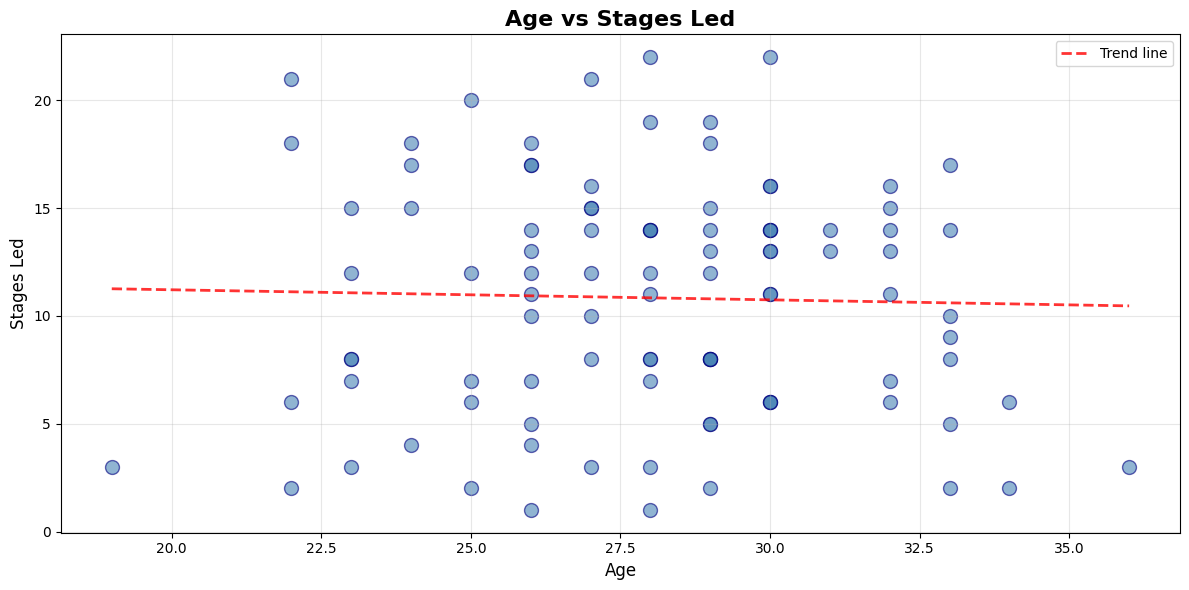

In [88]:
plt.figure(figsize=(12, 6))
plt.scatter(df_sorted['age'], df_sorted['stages_led'], alpha=0.6, s=100, c='steelblue', edgecolors='navy')
plt.title('Age vs Stages Led', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Stages Led', fontsize=12)
plt.grid(alpha=0.30)
z = np.polyfit(df_sorted['age'].dropna(), df_sorted['stages_led'].dropna(), 1)
p = np.poly1d(z)
plt.plot(df_sorted['age'].sort_values(), p(df_sorted['age'].sort_values()), 
         "r--", alpha=0.8, linewidth=2, label=f'Trend line')
plt.legend()

plt.tight_layout()
plt.show()

In [48]:
#plt.figure(figsize=(10, 6))
#sb.scatterplot(data=df_sorted,x='age', y='stages_led', hue='winner_name', s=100, alpha=0.7)
#plt.title('Relationship Between Age and Stages Led')
#plt.xlabel('Age')
#plt.ylabel('Stages Led')
#plt.legend(title='Winner', bbox_to_anchor=(1.05, 1))
#plt.grid(alpha=0.3)
#plt.tight_layout()
#plt.show()

In [44]:
heatmap_data = (df_sorted.groupby(['winner_name', 'age'])['stages_led'].mean().unstack(fill_value=0))

In [50]:
df_sorted['winner_name'].nunique()

56

In [49]:
# plt.figure(figsize=(14, 8))
# sb.heatmap(heatmap_data,cmap='YlGnBu',annot=True,fmt=".1f",cbar_kws={'label': 'Avg Stages Led'})
# plt.title('Average Stages Led by Winner and Age', fontsize=16, fontweight='bold')
# plt.xlabel('Age')
# plt.ylabel('Winner Name')
# plt.tight_layout()
# plt.show()

The two plots above were a scatter plot and heat map trying to find a correlation of the age and stages led for individual winners. 
This wil be explored soon using better visuaizations. Probably using the top winners since we have 56 unique names, making a visualization with that number is quite hard

In [32]:
correlation = df_sorted['age'].corr(df_sorted['stages_led'])
print(f"\nCorrelation between Age and Stages Led: {correlation:.3f}")


Correlation between Age and Stages Led: -0.028


In [33]:
df_sorted['age_group'] = pd.cut(df_sorted['age'], bins=[0, 23, 26, 29, 32, 100], labels=['≤23', '24-26', '27-29', '30-32', '33+'])

In [34]:
grouped_data = df_sorted.groupby(['age_group', 'stages_led'], observed=True).size().unstack(fill_value=0)

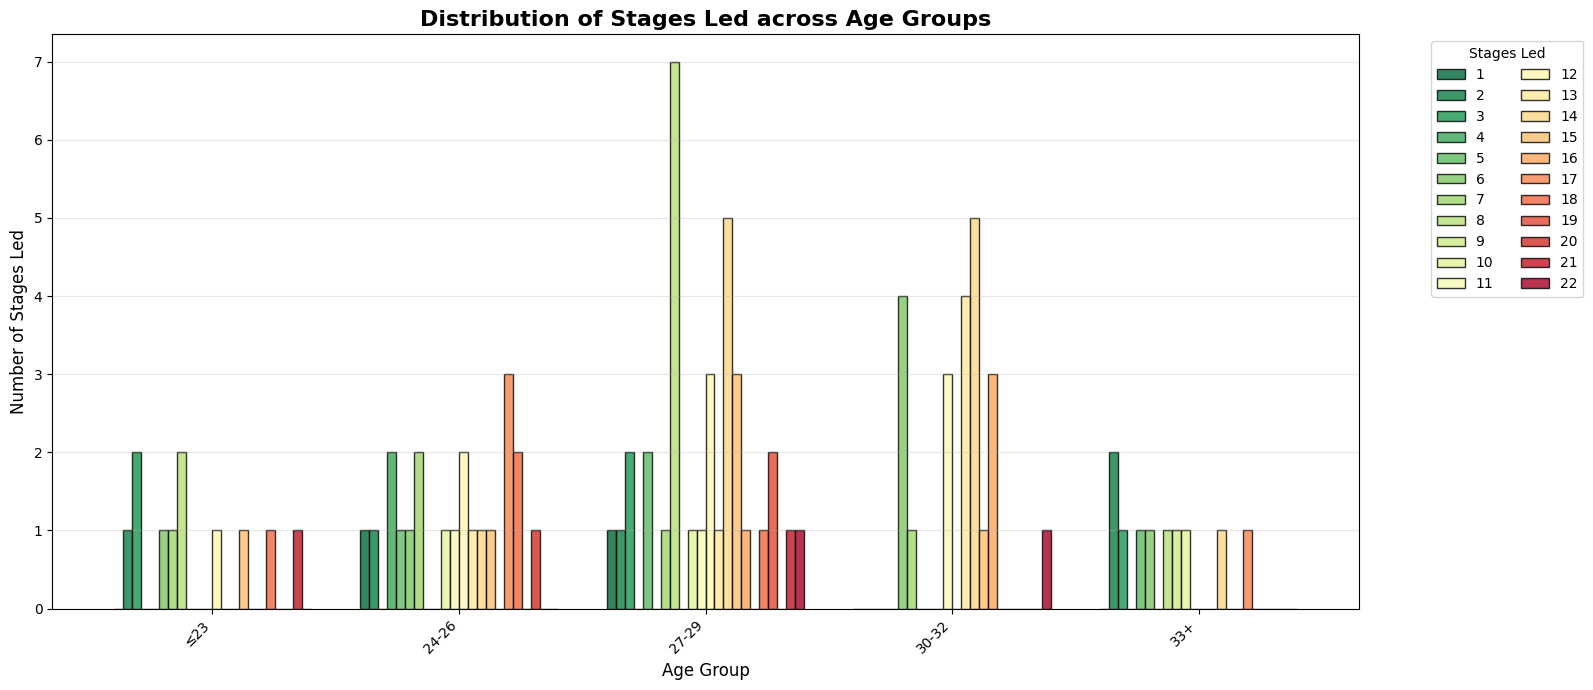

In [35]:
fig, ax = plt.subplots(figsize=(16, 7))
grouped_data.plot(kind='bar', ax=ax, width=0.8, cmap='RdYlGn_r', edgecolor='black', alpha=0.8)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Number of Stages Led', fontsize=12)
ax.set_title('Distribution of Stages Led across Age Groups', fontsize=16, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Stages Led', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
grouped_data = df_sorted.groupby('age_group', observed=True)['stages_led'].count()


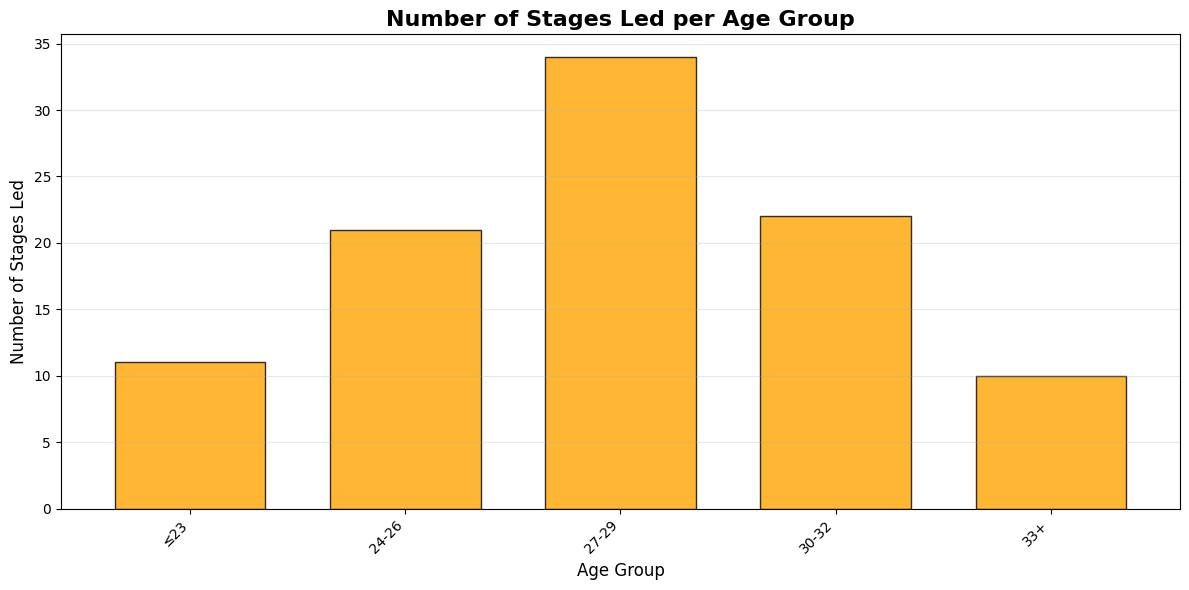

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))
grouped_data.plot(kind='bar',ax=ax,color='orange',edgecolor='black',alpha=0.8,width=0.7)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Number of Stages Led', fontsize=12)
ax.set_title('Number of Stages Led per Age Group', fontsize=16, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Question - What is the relation between age and the stages led.

Using the scatter plot above, the correlation was not very clear.
The pearson correlation coefficient shows there is no linear correlation between age and stages led. This is true.

However there is a correlation that is not linear. After placing the ages in groups, it is clear the athletes with more experience but still young(within their twenties) were able to lead more stages. The older they got the more scarce they were at leading the stages. The peak age for athletes is late twenties.

In [89]:
df_sorted.columns

Index(['edition', 'start_date', 'winner_name', 'winner_team', 'distance',
       'time_overall', 'time_margin', 'stage_wins', 'stages_led', 'height',
       'weight', 'age', 'born', 'died', 'full_name', 'nickname', 'birth_town',
       'birth_country', 'nationality'],
      dtype='object')

In [90]:
df_sorted['start_date'] = pd.to_datetime(df_sorted['start_date'], errors='coerce')

In [94]:
df_sorted['start_date'].dtype

dtype('<M8[ns]')

In [92]:
df_sorted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 0 to 105
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   edition        98 non-null     int64         
 1   start_date     98 non-null     datetime64[ns]
 2   winner_name    98 non-null     object        
 3   winner_team    98 non-null     object        
 4   distance       98 non-null     float64       
 5   time_overall   98 non-null     float64       
 6   time_margin    98 non-null     float64       
 7   stage_wins     98 non-null     int64         
 8   stages_led     98 non-null     int64         
 9   height         65 non-null     float64       
 10  weight         66 non-null     float64       
 11  age            98 non-null     int64         
 12  born           98 non-null     object        
 13  died           48 non-null     object        
 14  full_name      43 non-null     object        
 15  nickname       70 non-null   

In [98]:
df_sorted.sort_values('start_date', ascending=False, inplace=True)

In [99]:
df_sorted.head(10)

,edition,start_date,winner_name,winner_team,distance,time_overall,time_margin,stage_wins,stages_led,height,weight,age,born,died,full_name,nickname,birth_town,birth_country,nationality
105,106,2019-07-06,Egan Bernal,Team Ineos,3349.0,82.950000,0.016944,0,2,1.75,60.0,22,1997-01-13,NaN,Egan Arley Bernal Gómez,NaN,Bogotá,Columbia,Colombia
104,105,2018-07-07,Geraint Thomas,Team Sky,3349.0,83.286944,0.016944,2,11,1.83,71.0,32,1986-05-25,NaN,Geraint Howell Thomas,G,Cardiff,Wales,Great Britain
103,104,2017-07-01,Chris Froome,Team Sky,3540.0,86.348611,0.015000,0,15,1.86,69.0,32,1985-05-20,NaN,Christopher Clive Froome,Froomey,Nairobi,Kenya,Great Britain
102,103,2016-07-02,Chris Froome,Team Sky,3529.0,89.080000,0.067778,2,14,1.86,69.0,31,1985-05-20,NaN,Christopher Clive Froome,Froomey,Nairobi,Kenya,Great Britain
101,102,2015-07-04,Chris Froome,Team Sky,3360.3,84.770556,0.016944,1,16,1.86,69.0,30,1985-05-20,NaN,Christopher Clive Froome,Froomey,Nairobi,Kenya,Great Britain
100,101,2014-07-05,Vincenzo Nibali,Astana,3660.5,89.985000,0.118611,4,19,1.80,65.0,29,1984-11-14,NaN,NaN,"Lo Squalo (The Shark), 'il Roditore' (The Nibb...",Messina,Italy,Italy
99,100,2013-06-29,Chris Froome,Team Sky,3404.0,83.938889,0.067778,3,14,1.86,69.0,28,1985-05-20,NaN,Christopher Clive Froome,Froomey,Nairobi,Kenya,Great Britain
98,99,2012-06-20,Bradley Wiggins,Team Sky,3496.0,87.579722,0.050833,2,14,1.90,69.0,32,1980-04-28,NaN,Bradley Marc Wiggins,Wiggo,Ghent,Belgium,Great Britain
97,98,2011-07-02,Cadel Evans,BMC Racing Team,3430.0,86.206111,0.016944,1,2,1.74,64.0,34,1977-02-14,NaN,Cadel Lee Evans,NaN,Katherine,Australia,Australia
96,97,2010-07-03,Andy Schleck,Team Saxo Bank,3642.0,91.990833,0.016944,2,12,1.86,68.0,25,1985-06-10,NaN,Andy Raymond Schleck,NaN,Luxembourg City,Luxembourg,Luxembourg


In [101]:
top_recent = df_sorted[['edition','start_date','winner_name','nationality','birth_country']].head(10)
print(top_recent)

     edition start_date      winner_name     nationality birth_country
105      106 2019-07-06      Egan Bernal        Colombia      Columbia
104      105 2018-07-07   Geraint Thomas   Great Britain         Wales
103      104 2017-07-01     Chris Froome   Great Britain         Kenya
102      103 2016-07-02     Chris Froome   Great Britain         Kenya
101      102 2015-07-04     Chris Froome   Great Britain         Kenya
100      101 2014-07-05  Vincenzo Nibali           Italy         Italy
99       100 2013-06-29     Chris Froome   Great Britain         Kenya
98        99 2012-06-20  Bradley Wiggins   Great Britain       Belgium
97        98 2011-07-02      Cadel Evans       Australia     Australia
96        97 2010-07-03     Andy Schleck      Luxembourg    Luxembourg


In [103]:
nationality_counts = top_recent['nationality'].value_counts()

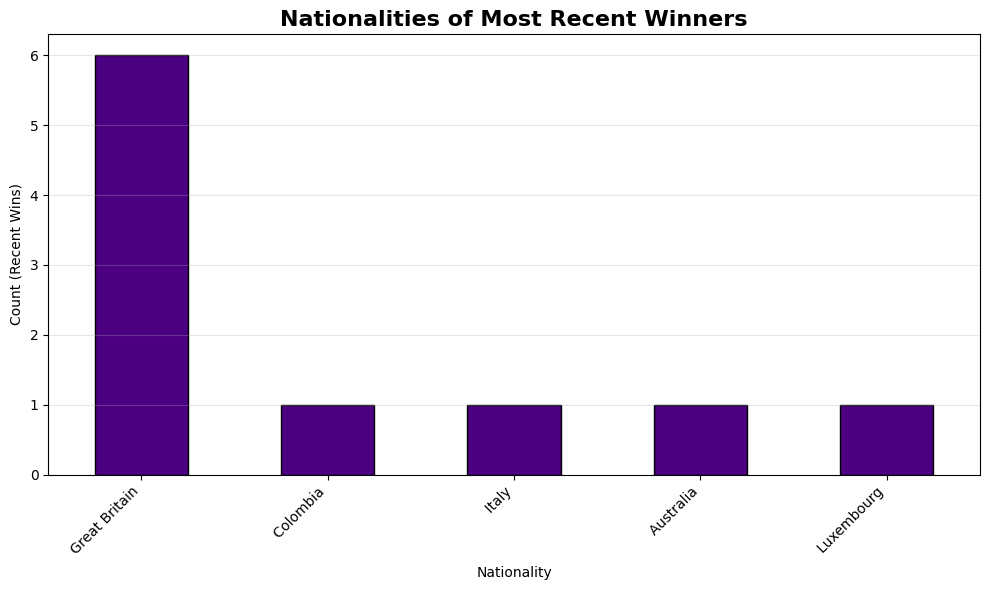

In [107]:
plt.figure(figsize=(10,6))
nationality_counts.plot(kind='bar', color='indigo', edgecolor='black')
plt.title('Nationalities of Most Recent Winners', fontsize=16, fontweight='bold')
plt.xlabel('Nationality')
plt.ylabel('Count (Recent Wins)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [108]:
top_recent['year'] = top_recent['start_date'].dt.year

In [109]:
print(top_recent)

     edition start_date      winner_name     nationality birth_country  year
105      106 2019-07-06      Egan Bernal        Colombia      Columbia  2019
104      105 2018-07-07   Geraint Thomas   Great Britain         Wales  2018
103      104 2017-07-01     Chris Froome   Great Britain         Kenya  2017
102      103 2016-07-02     Chris Froome   Great Britain         Kenya  2016
101      102 2015-07-04     Chris Froome   Great Britain         Kenya  2015
100      101 2014-07-05  Vincenzo Nibali           Italy         Italy  2014
99       100 2013-06-29     Chris Froome   Great Britain         Kenya  2013
98        99 2012-06-20  Bradley Wiggins   Great Britain       Belgium  2012
97        98 2011-07-02      Cadel Evans       Australia     Australia  2011
96        97 2010-07-03     Andy Schleck      Luxembourg    Luxembourg  2010


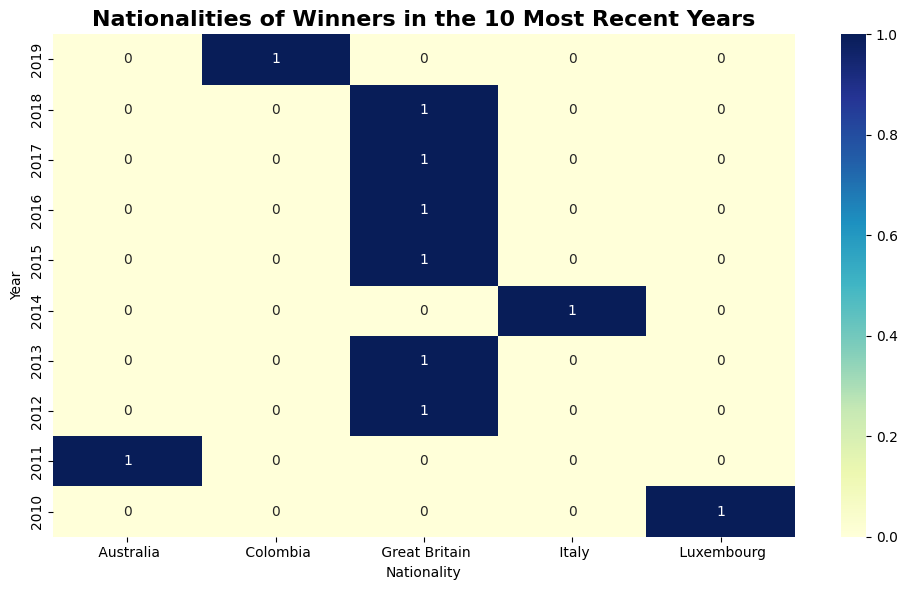

In [117]:
heat_data = (top_recent.groupby(['year', 'nationality']).size().unstack(fill_value=0))

plt.figure(figsize=(10,6))
sb.heatmap(heat_data,annot=True,fmt='d',cmap='YlGnBu')
plt.title('Nationalities of Winners in the 10 Most Recent Years', fontsize=16, fontweight='bold')
plt.xlabel('Nationality')
plt.ylabel('Year')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

Question - The most recent winning and the winners nationality.

- The bar chart shows that Great Britain is the nationality with the highest number recent winnings. Six out of the top ten.

- The heat map also shows the same but also allows us to see that Columbia was the nationailty of the most recent winning.